Import Data

In [142]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

Load Data

In [60]:
pd.set_option('display.max_columns', None)
df = pd.read_csv("data_A.csv")
df.head()

,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0,0xa658,CUS_0x936d,March,Alistair Barrs,8466,703-48-3482,_______,100433.58,8074.465000,1,5,10,2,"Student Loan, and Debt Consolidation Loan",13,4,12.59,3.0,Good,1023.93,33.471395,20 Years and 5 Months,No,100.163466,758.0704866746678,Low_spent_Medium_value_payments,229.21254743638283,Standard
1,1,0x6739,CUS_0x9a29,August,Phila,25,339-28-0072,Developer,33119.82,3024.985000,10,5,32,5,"Home Equity Loan, Mortgage Loan, Home Equity L...",50,18,15.79,10.0,Bad,2545.0,33.810567,14 Years and 8 Months,Yes,111.422702,NaN,Low_spent_Small_value_payments,370.6074980582689,Poor
2,2,0xdcf5,CUS_0x12a9,April,Driverb,44,583-20-9758,_______,44822.21,3555.184167,1,4,2,4,"Credit-Builder Loan, Debt Consolidation Loan, ...",14,8,4.03,0.0,Good,730.64,31.145739,23 Years and 10 Months,NM,135.044286,256.4742969677053,Low_spent_Medium_value_payments,243.99983412342044,Standard
3,3,0x14453,CUS_0x3bad,June,Prasadc,29,510-25-2095,Musician,142081.48,11771.123333,6,6,15,3_,"Personal Loan, Not Specified, and Mortgage Loan",29,20,8.21,4.0,Standard,932.32,28.409526,27 Years and 0 Months,No,180.616478,423.96126196668365,Low_spent_Small_value_payments,862.534593039876,Standard
4,4,0x1198e,CUS_0xa3e1,January,Poornimai,45,943-92-4350,Scientist,19267.27_,1374.605833,10,8,25,6,"Home Equity Loan, Auto Loan, Payday Loan, Not ...",33,NaN,19.7,6.0,Bad,3777.55,28.373426,10 Years and 3 Months,Yes,78.954825,133.56850235207634,Low_spent_Small_value_payments,214.93725572483646,Poor


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                25000 non-null  int64  
 1   ID                        25000 non-null  object 
 2   Customer_ID               25000 non-null  object 
 3   Month                     25000 non-null  object 
 4   Name                      22440 non-null  object 
 5   Age                       25000 non-null  object 
 6   SSN                       25000 non-null  object 
 7   Occupation                25000 non-null  object 
 8   Annual_Income             25000 non-null  object 
 9   Monthly_Inhand_Salary     21417 non-null  float64
 10  Num_Bank_Accounts         25000 non-null  int64  
 11  Num_Credit_Card           25000 non-null  int64  
 12  Interest_Rate             25000 non-null  int64  
 13  Num_of_Loan               25000 non-null  object 
 14  Type_o

Drop Unnecessary Column

In [62]:
df = df = df.drop(columns=["Unnamed: 0", "ID", "SSN", "Customer_ID", "Name"], axis=1)

Drop Duplicates

In [63]:
df.duplicated().sum()
df = df.drop_duplicates()

Reveal INCONSISTENT

In [64]:
for col in df.columns:
    unique_vals = df[col].nunique(dropna=False)
    if unique_vals <= 20:
        print(f"--- {col} ({unique_vals} unique values) ---")
        print(df[col].value_counts(dropna=False))
        print("\n")

--- Month (8 unique values) ---
Month
April       3173
July        3156
May         3151
March       3139
June        3131
August      3100
February    3087
January     3063
Name: count, dtype: int64


--- Occupation (16 unique values) ---
Occupation
_______          1770
Engineer         1650
Lawyer           1618
Architect        1613
Media_Manager    1575
Accountant       1569
Entrepreneur     1559
Developer        1556
Scientist        1553
Teacher          1552
Mechanic         1529
Journalist       1523
Doctor           1519
Manager          1483
Musician         1474
Writer           1457
Name: count, dtype: int64


--- Credit_Mix (4 unique values) ---
Credit_Mix
Standard    9137
Good        6006
_           5066
Bad         4791
Name: count, dtype: int64


--- Payment_of_Min_Amount (3 unique values) ---
Payment_of_Min_Amount
Yes    13160
No      8840
NM      3000
Name: count, dtype: int64


--- Payment_Behaviour (7 unique values) ---
Payment_Behaviour
Low_spent_Small_value_paym

In [65]:
df['Credit_Mix'].unique()

array(['Good', 'Bad', 'Standard', '_'], dtype=object)

In [66]:
df['Payment_of_Min_Amount'].unique()

array(['No', 'Yes', 'NM'], dtype=object)

In [67]:
df['Payment_Behaviour'].unique()

array(['Low_spent_Medium_value_payments',
       'Low_spent_Small_value_payments',
       'High_spent_Large_value_payments',
       'Low_spent_Large_value_payments', '!@9#%8',
       'High_spent_Medium_value_payments',
       'High_spent_Small_value_payments'], dtype=object)

In [68]:
df['Occupation'].unique()

array(['_______', 'Developer', 'Musician', 'Scientist', 'Entrepreneur',
       'Accountant', 'Journalist', 'Media_Manager', 'Mechanic', 'Writer',
       'Doctor', 'Teacher', 'Lawyer', 'Engineer', 'Architect', 'Manager'],
      dtype=object)

In [69]:
#Handling
df['Credit_Mix'] = df['Credit_Mix'].replace('_', np.nan)

df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].replace('NM', np.nan)

df['Payment_Behaviour'] = df['Payment_Behaviour'].replace('!@9#%8', np.nan)

df['Occupation'] = df['Occupation'].replace('_______', np.nan)

Make New Columns

In [70]:
df['Spent'] = df['Payment_Behaviour'].str.split('_').str[0].str.lower()

df['Value_Payment'] = df['Payment_Behaviour'].str.split('_').str[2].str.lower()

print(df[['Payment_Behaviour', 'Spent', 'Value_Payment']])
df = df.drop(['Payment_Behaviour'], axis= 1)

                      Payment_Behaviour Spent Value_Payment
0       Low_spent_Medium_value_payments   low        medium
1        Low_spent_Small_value_payments   low         small
2       Low_spent_Medium_value_payments   low        medium
3        Low_spent_Small_value_payments   low         small
4        Low_spent_Small_value_payments   low         small
...                                 ...   ...           ...
24995   High_spent_Small_value_payments  high         small
24996  High_spent_Medium_value_payments  high        medium
24997    Low_spent_Small_value_payments   low         small
24998                               NaN   NaN           NaN
24999    Low_spent_Small_value_payments   low         small

[25000 rows x 3 columns]


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     25000 non-null  object 
 1   Age                       25000 non-null  object 
 2   Occupation                23230 non-null  object 
 3   Annual_Income             25000 non-null  object 
 4   Monthly_Inhand_Salary     21417 non-null  float64
 5   Num_Bank_Accounts         25000 non-null  int64  
 6   Num_Credit_Card           25000 non-null  int64  
 7   Interest_Rate             25000 non-null  int64  
 8   Num_of_Loan               25000 non-null  object 
 9   Type_of_Loan              22172 non-null  object 
 10  Delay_from_due_date       25000 non-null  int64  
 11  Num_of_Delayed_Payment    23267 non-null  object 
 12  Changed_Credit_Limit      25000 non-null  object 
 13  Num_Credit_Inquiries      24494 non-null  float64
 14  Credit

In [72]:
df["Type_of_Loan"].unique()

array(['Student Loan, and Debt Consolidation Loan',
       'Home Equity Loan, Mortgage Loan, Home Equity Loan, Debt Consolidation Loan, and Not Specified',
       'Credit-Builder Loan, Debt Consolidation Loan, Payday Loan, and Debt Consolidation Loan',
       ...,
       'Credit-Builder Loan, Personal Loan, Not Specified, Auto Loan, Credit-Builder Loan, Credit-Builder Loan, and Credit-Builder Loan',
       'Credit-Builder Loan, Mortgage Loan, Home Equity Loan, Not Specified, Debt Consolidation Loan, Credit-Builder Loan, Home Equity Loan, Auto Loan, and Not Specified',
       'Not Specified, Auto Loan, Payday Loan, Credit-Builder Loan, Student Loan, and Mortgage Loan'],
      shape=(5741,), dtype=object)

In [73]:
#for transforming multi-label data into a binary format.
import re
def parse_type_of_loan(x):
    if pd.isna(x):
        return []
    x = re.sub(r'\s+and\s+', ', ', x)
    return list(set(i.strip() for i in x.split(',') if i.strip()))

df['Type_of_Loan_list'] = df['Type_of_Loan'].apply(parse_type_of_loan)

In [74]:
df['Type_of_Loan_list']
df['loan_missing'] = (df['Type_of_Loan'].isna()).astype(int)

In [75]:
df['loan_missing'].value_counts()

loan_missing
0    22172
1     2828
Name: count, dtype: int64

In [76]:
from sklearn.preprocessing import MultiLabelBinarizer
mlb = MultiLabelBinarizer()
loan_ohe = pd.DataFrame(
    mlb.fit_transform(df['Type_of_Loan_list']),
    columns=mlb.classes_,
    index=df.index
)
df = pd.concat([df, loan_ohe], axis=1)
df.drop(columns=['Type_of_Loan', 'Type_of_Loan_list'], inplace=True)

In [77]:
years = df['Credit_History_Age'].str.extract('(\d+) Years').astype(float)
months = df['Credit_History_Age'].str.extract('(\d+) Months').astype(float)
df['Credit_History_Age'] = years + (months / 12)

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     25000 non-null  object 
 1   Age                       25000 non-null  object 
 2   Occupation                23230 non-null  object 
 3   Annual_Income             25000 non-null  object 
 4   Monthly_Inhand_Salary     21417 non-null  float64
 5   Num_Bank_Accounts         25000 non-null  int64  
 6   Num_Credit_Card           25000 non-null  int64  
 7   Interest_Rate             25000 non-null  int64  
 8   Num_of_Loan               25000 non-null  object 
 9   Delay_from_due_date       25000 non-null  int64  
 10  Num_of_Delayed_Payment    23267 non-null  object 
 11  Changed_Credit_Limit      25000 non-null  object 
 12  Num_Credit_Inquiries      24494 non-null  float64
 13  Credit_Mix                19934 non-null  object 
 14  Outsta

Variable Type

In [79]:
df["Age"] = df["Age"].str.strip("_").astype(int)

df["Annual_Income"] = df["Annual_Income"].str.strip("_").astype(float)

df["Num_of_Loan"] = df["Num_of_Loan"].str.strip("_").astype(int)

df["Num_of_Delayed_Payment"] = df["Num_of_Delayed_Payment"].str.strip("_").astype(float)

df["Changed_Credit_Limit"] = pd.to_numeric(df["Changed_Credit_Limit"].str.strip("_"), errors='coerce')
df["Changed_Credit_Limit"] = df["Changed_Credit_Limit"].astype(float)

df["Outstanding_Debt"] = df["Outstanding_Debt"].str.strip("_").astype(float)

df["Amount_invested_monthly"] = df["Amount_invested_monthly"].str.strip("_").astype(float)

df = df[df["Monthly_Balance"] != "__-333333333333333333333333333__"]
df["Monthly_Balance"] = df["Monthly_Balance"].str.strip("_").astype(float)

In [80]:
(df.isna().sum() / len(df)) * 100

Month                        0.000000
Age                          0.000000
Occupation                   7.077132
Annual_Income                0.000000
Monthly_Inhand_Salary       14.334293
Num_Bank_Accounts            0.000000
Num_Credit_Card              0.000000
Interest_Rate                0.000000
Num_of_Loan                  0.000000
Delay_from_due_date          0.000000
Num_of_Delayed_Payment       6.933109
Changed_Credit_Limit         2.072332
Num_Credit_Inquiries         2.024324
Credit_Mix                  20.259241
Outstanding_Debt             0.000000
Credit_Utilization_Ratio     0.000000
Credit_History_Age           8.993439
Payment_of_Min_Amount       11.993919
Total_EMI_per_month          0.000000
Amount_invested_monthly      4.656745
Monthly_Balance              1.156185
Credit_Score                 0.000000
Spent                        7.409185
Value_Payment                7.409185
loan_missing                 0.000000
Auto Loan                    0.000000
Credit-Build

EDA

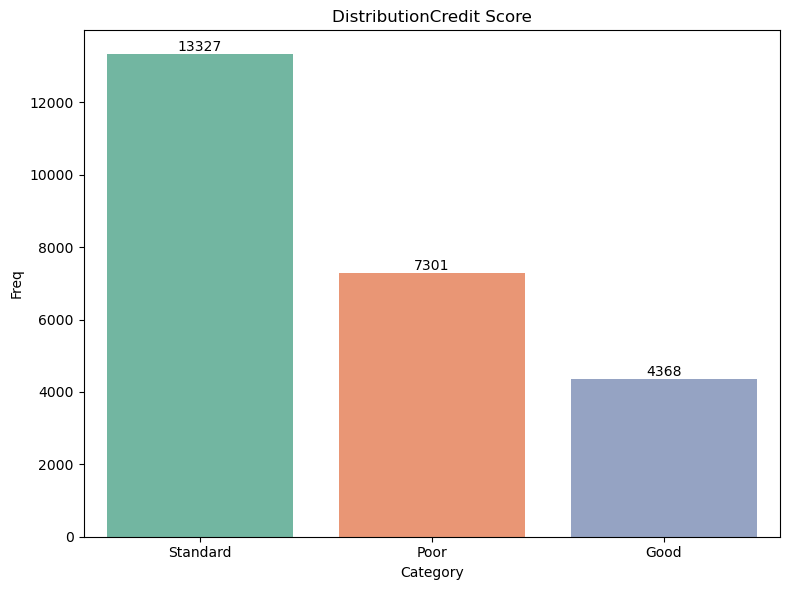

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))

ax = sns.countplot(data=df, x='Credit_Score', hue='Credit_Score', palette='Set2', legend=False)

for container in ax.containers:
    ax.bar_label(container)

plt.title('DistributionCredit Score')
plt.xlabel('Category')
plt.ylabel('Freq')

plt.tight_layout()
plt.show()

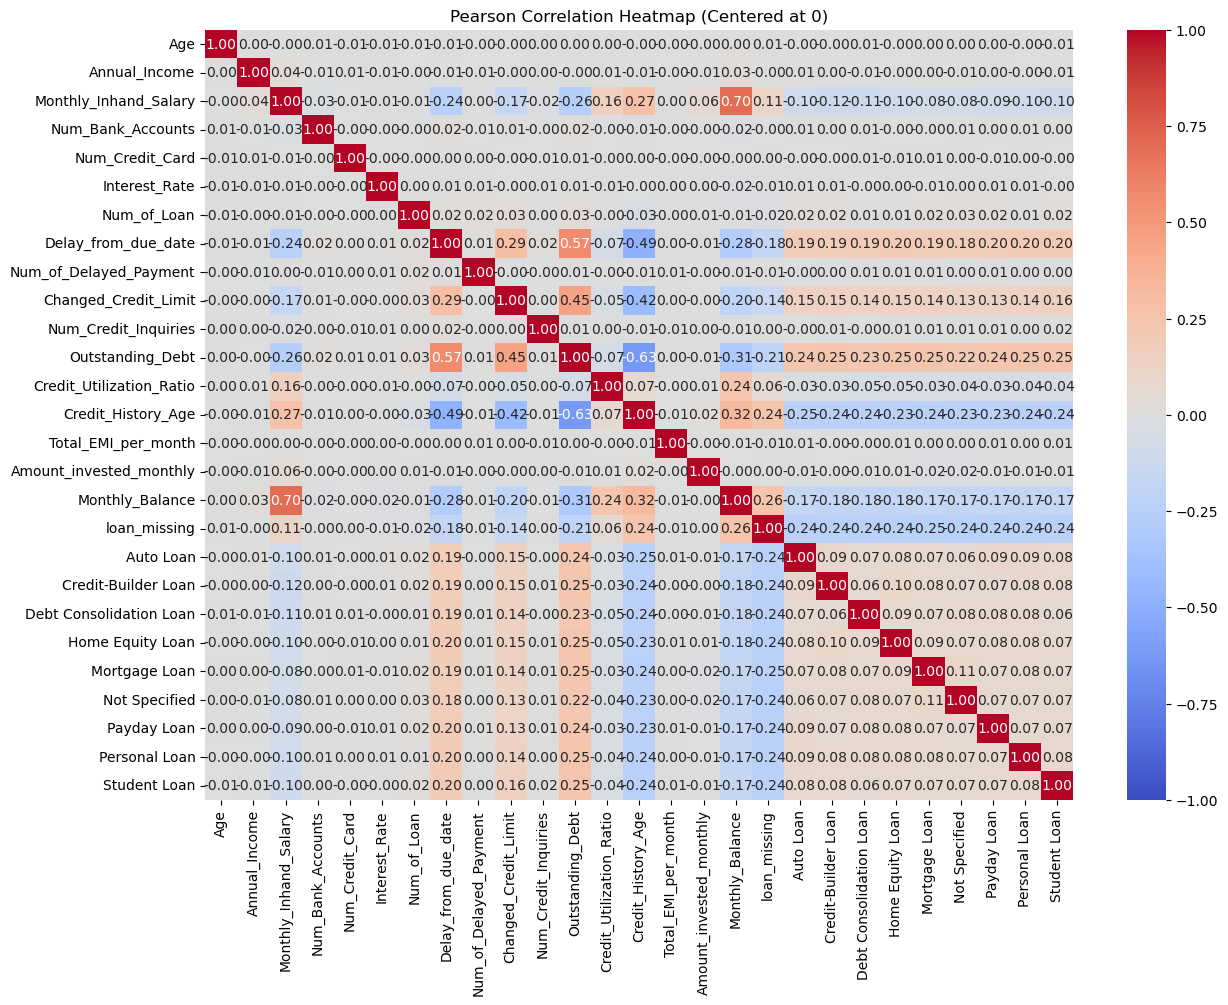

In [82]:
numerical_columns = df.select_dtypes(include=['number']).columns

corr_matrix = df[numerical_columns].corr(method='pearson')

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f"  
)
plt.title("Pearson Correlation Heatmap (Centered at 0)")
plt.show()

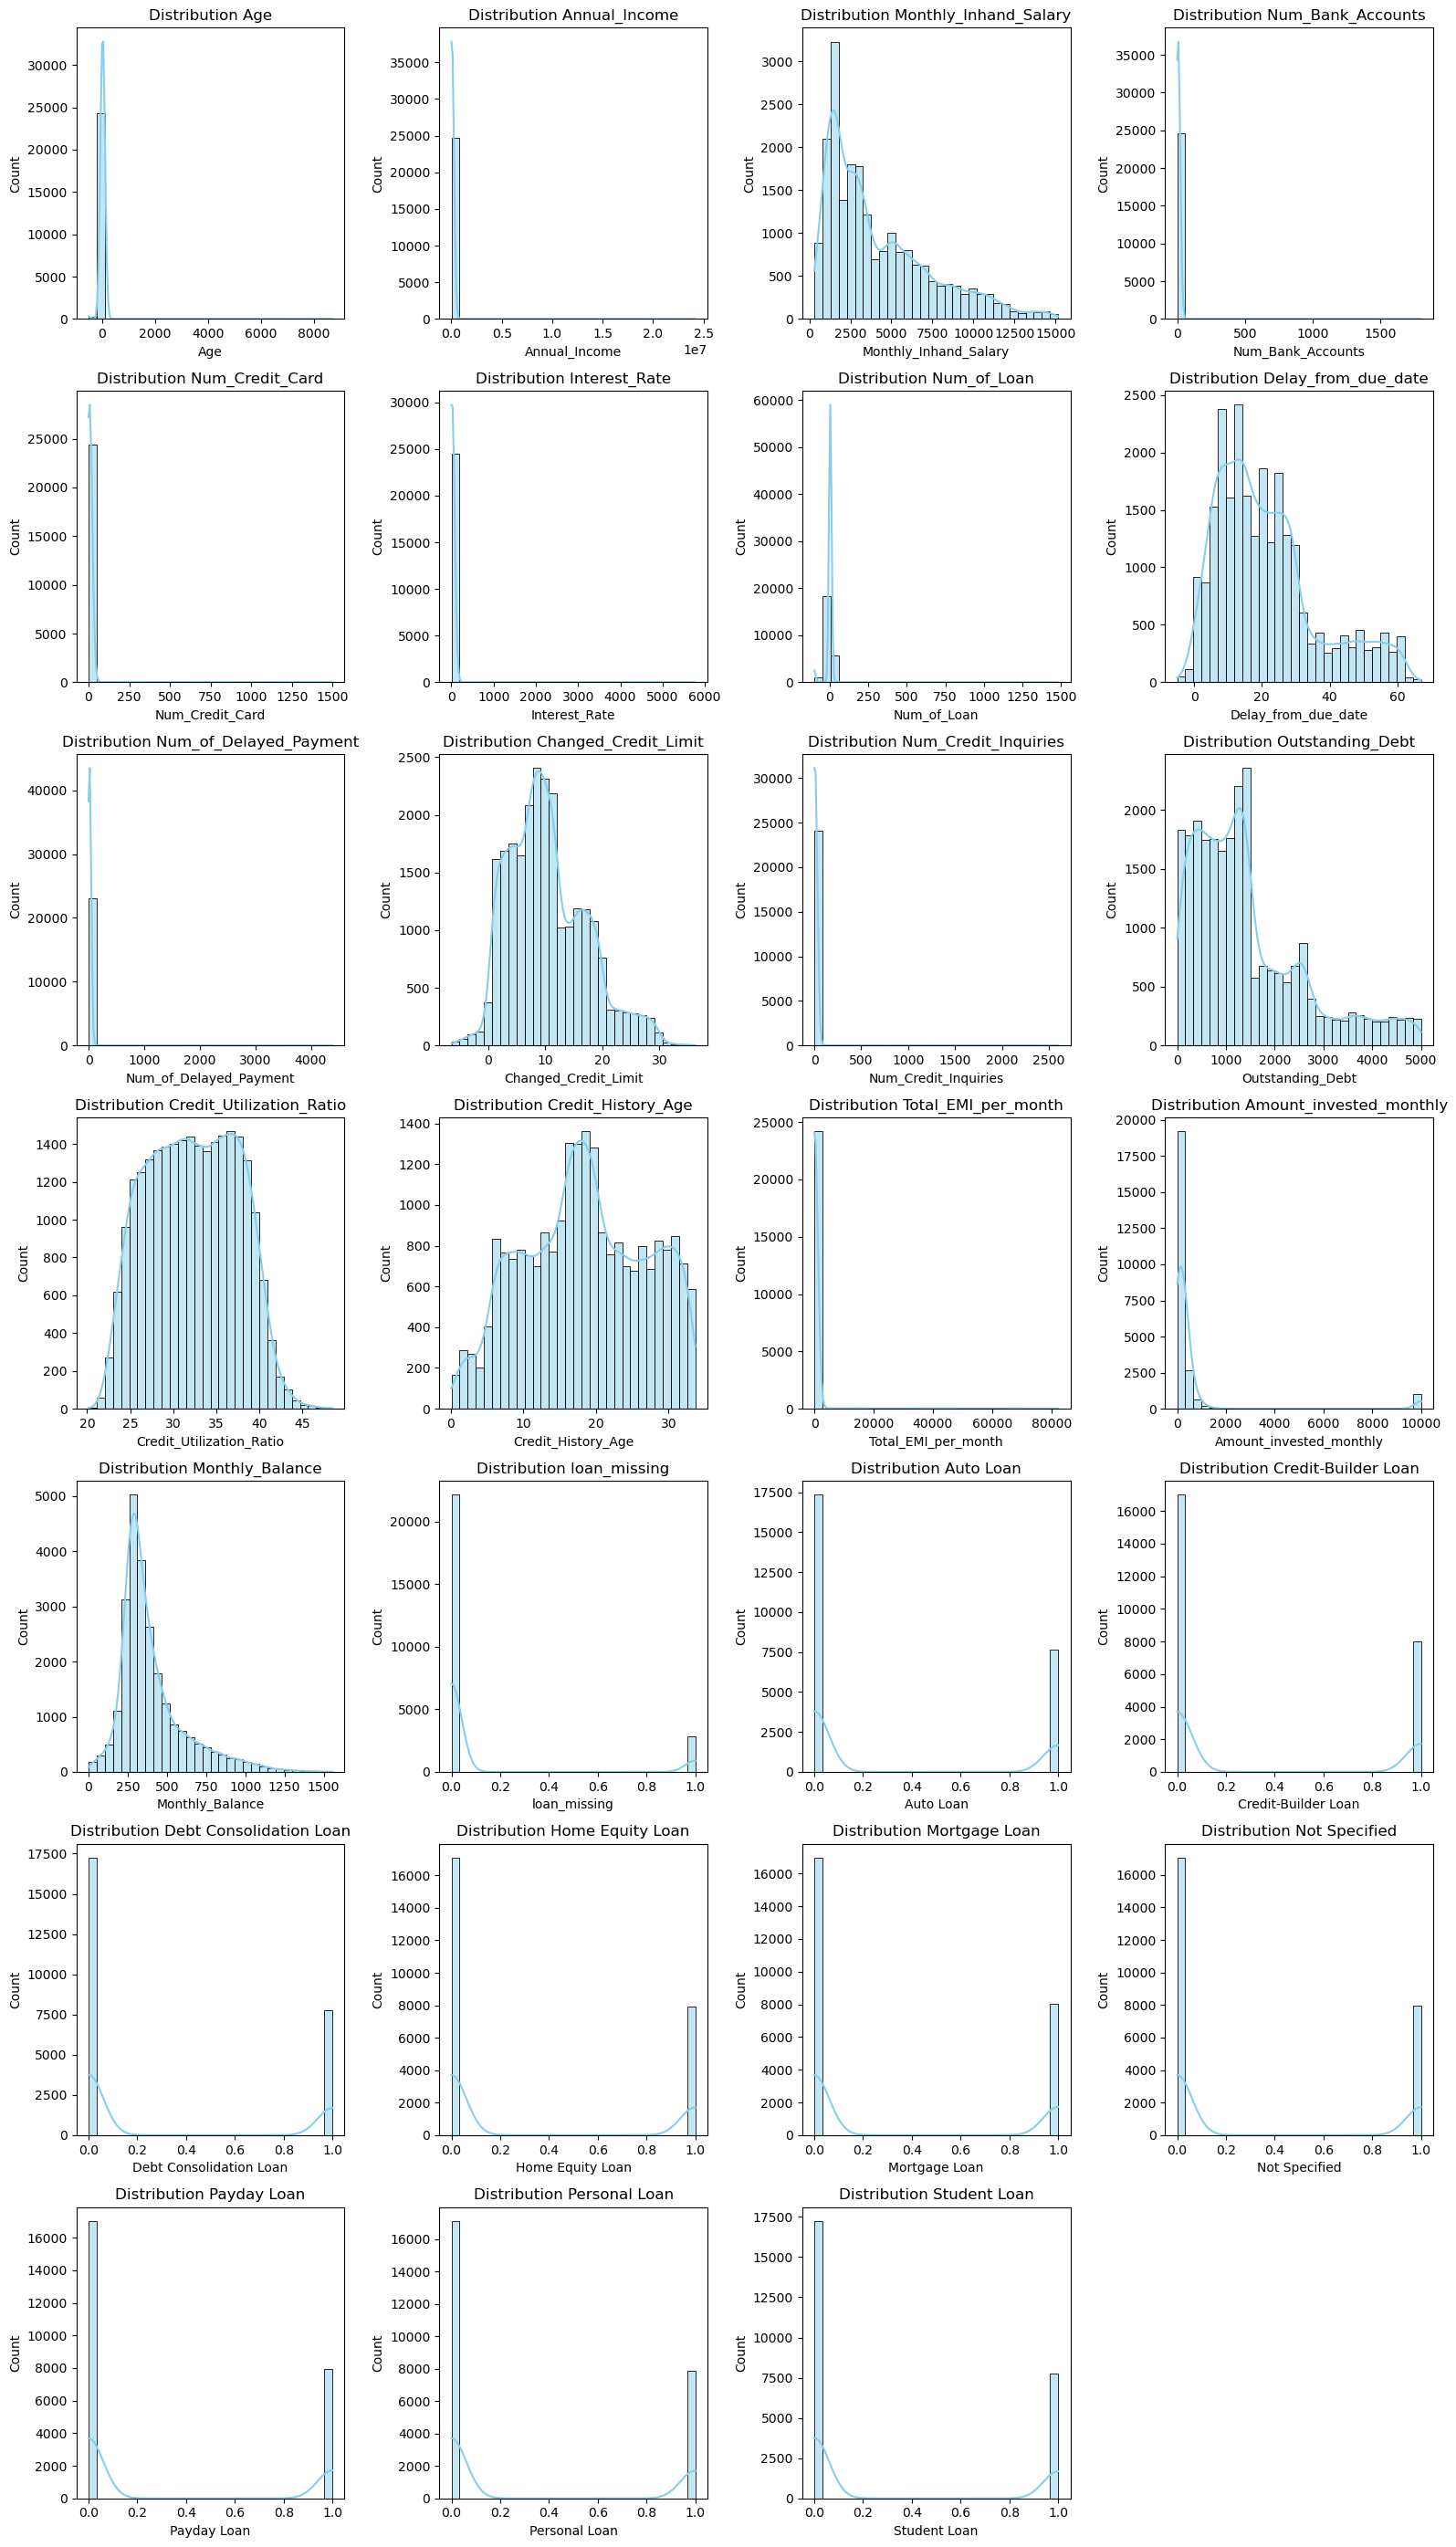

In [83]:
import math
jumlah_kolom = len(numerical_columns)

kolom_grid = 4
baris_grid = math.ceil(jumlah_kolom / kolom_grid)

plt.figure(figsize=(16, 4 * baris_grid))

for i, col in enumerate(numerical_columns, 1):
    plt.subplot(baris_grid, kolom_grid, i)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution {col}')

plt.tight_layout()
plt.show()

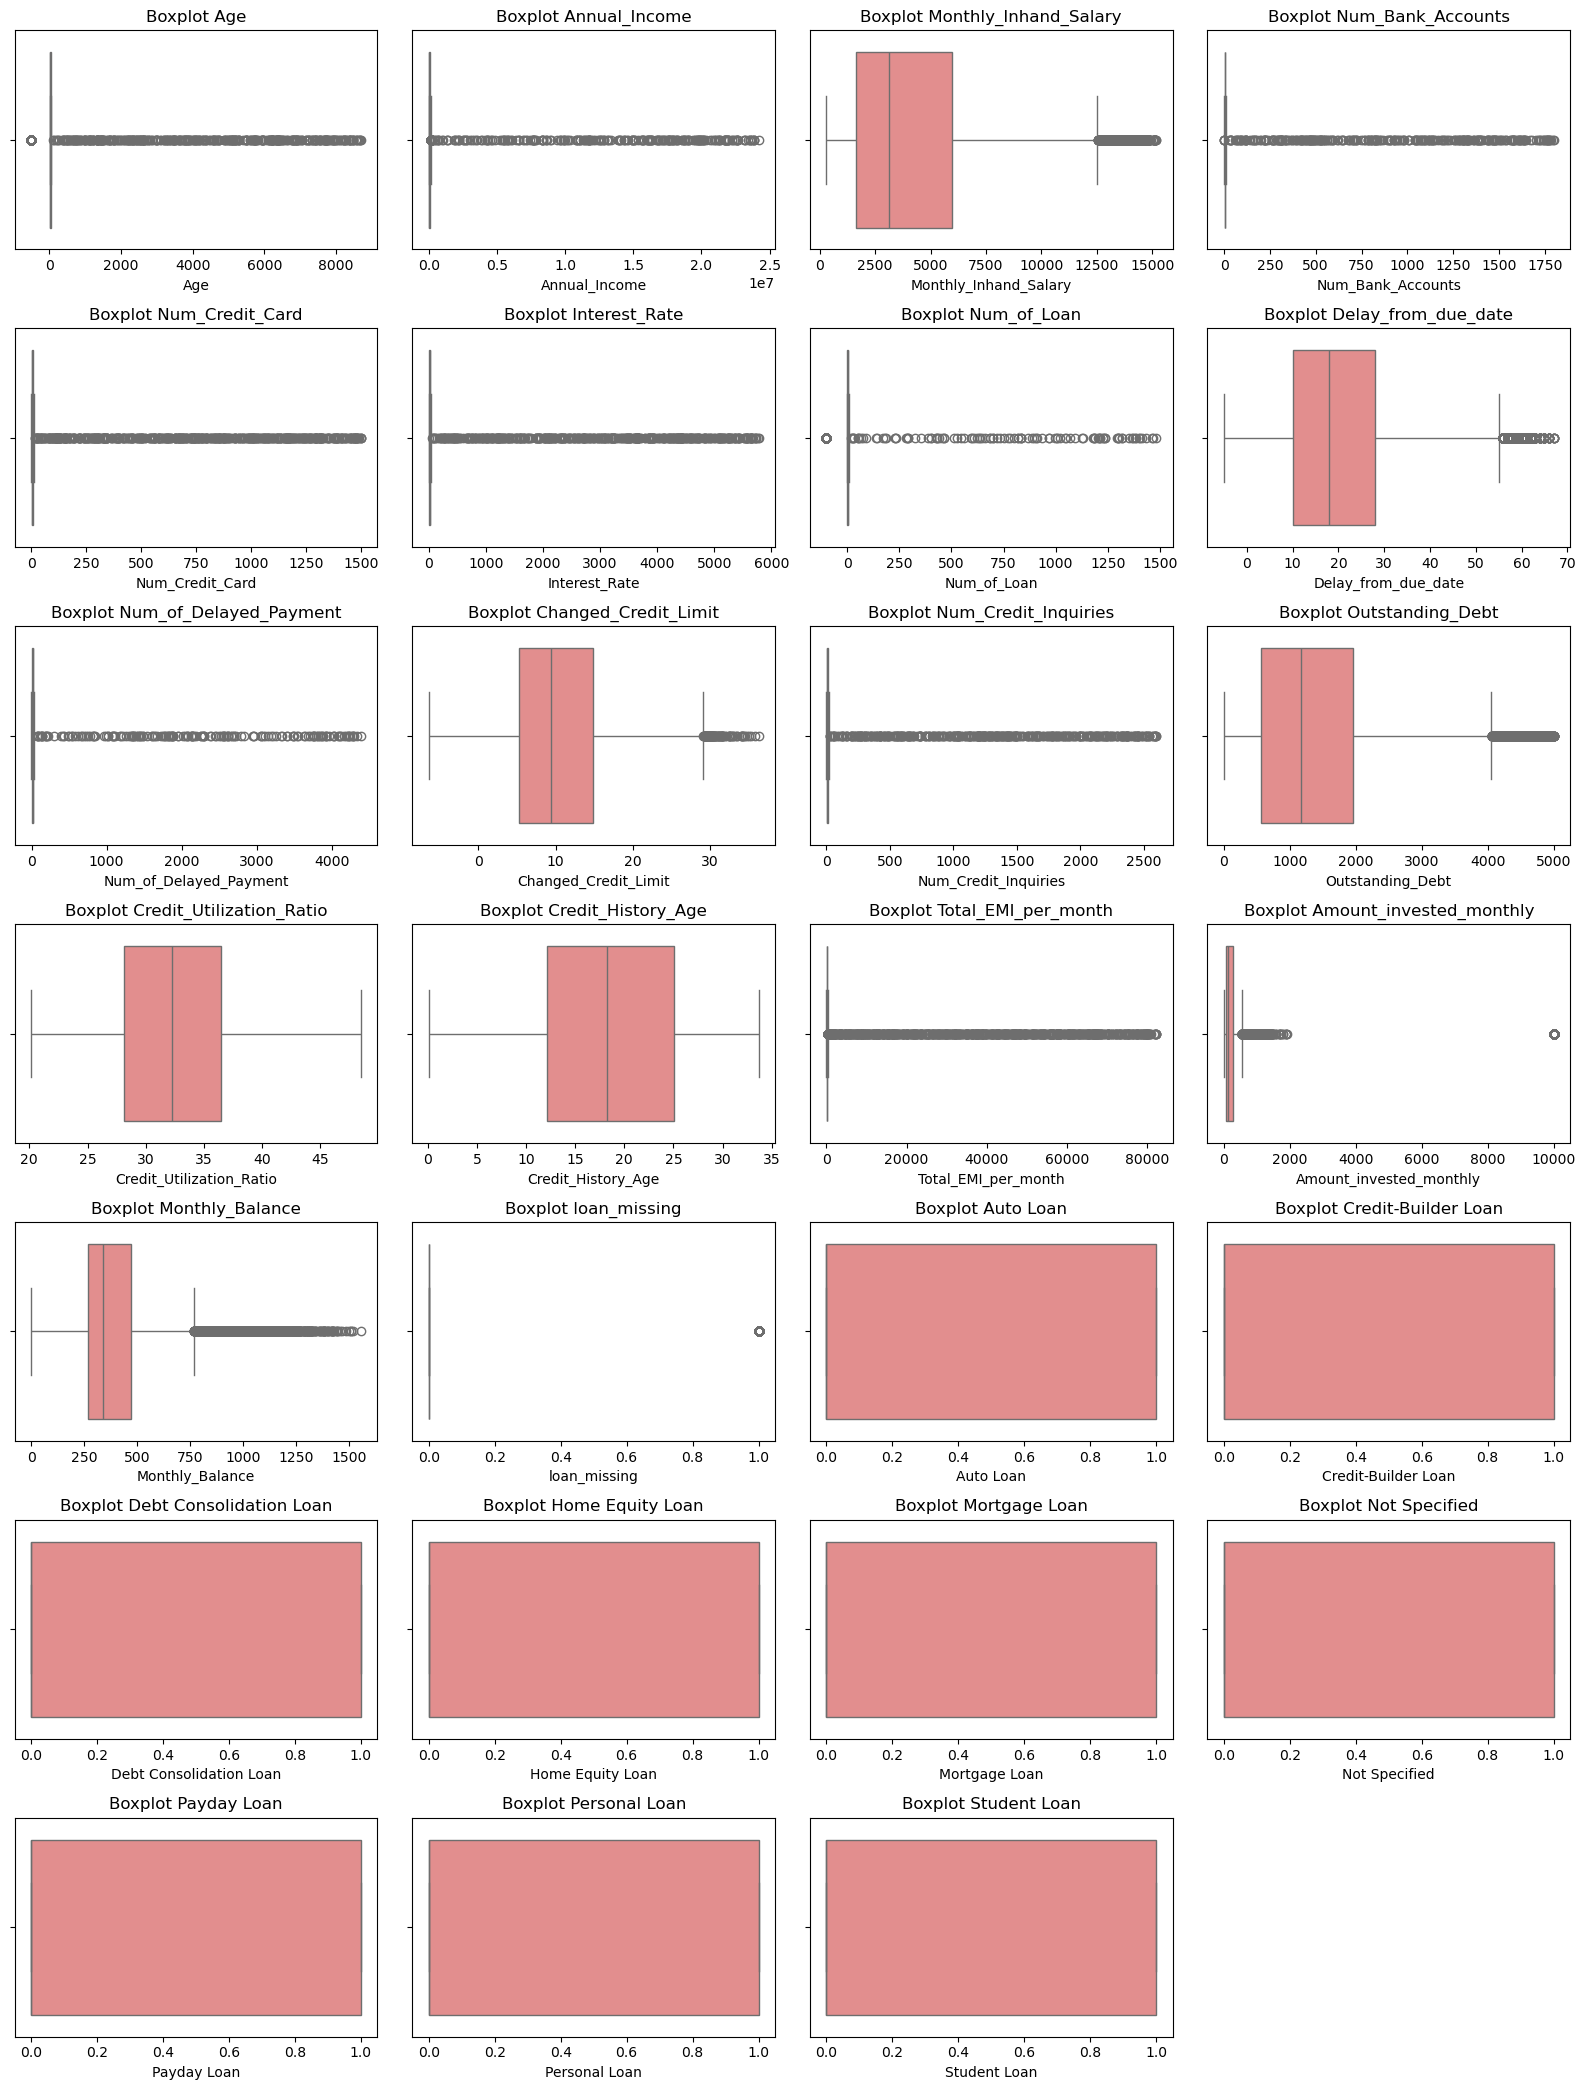

In [84]:
plt.figure(figsize=(16, 3 * baris_grid))

for i, col in enumerate(numerical_columns, 1):
    plt.subplot(baris_grid, kolom_grid, i)
    sns.boxplot(x=df[col], color='lightcoral')
    plt.title(f'Boxplot {col}')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

Filtering

In [85]:
#Describe Statistics
df[numerical_columns].describe(percentiles=[0.01, 0.05, 0.95, 0.99])

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,loan_missing,Auto Loan,Credit-Builder Loan,Debt Consolidation Loan,Home Equity Loan,Mortgage Loan,Not Specified,Payday Loan,Personal Loan,Student Loan
count,24996.000000,2.499600e+04,21413.000000,24996.000000,24996.000000,24996.000000,24996.000000,24996.000000,23263.000000,24478.000000,24490.000000,24996.000000,24996.000000,22748.000000,24996.000000,23832.000000,24707.000000,24996.000000,24996.000000,24996.000000,24996.000000,24996.000000,24996.000000,24996.000000,24996.000000,24996.000000,24996.000000
mean,105.217795,1.918275e+05,4215.584749,17.237278,22.145623,71.223196,2.847096,21.193551,30.401668,10.380971,28.153328,1430.462775,32.295906,18.384045,1405.791440,622.658928,401.845203,0.113138,0.305409,0.319451,0.309930,0.316211,0.321291,0.317651,0.318531,0.315090,0.309850
std,663.370035,1.531999e+06,3187.514164,118.316847,127.711878,463.705587,61.779098,14.887796,222.636143,6.768510,194.468590,1157.422738,5.090759,8.277934,8242.597616,2007.866395,212.886045,0.316768,0.460590,0.466273,0.462474,0.465005,0.466982,0.465572,0.465916,0.464561,0.462441
min,-500.000000,7.005930e+03,303.645417,-1.000000,0.000000,1.000000,-100.000000,-5.000000,-3.000000,-6.430000,0.000000,0.230000,20.172942,0.083333,0.000000,0.000000,0.899335,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1%,14.000000,7.587490e+03,544.573083,0.000000,1.000000,1.000000,-100.000000,0.000000,0.000000,-1.402300,0.000000,26.420000,22.772378,1.416667,0.000000,16.403972,66.318689,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5%,16.000000,9.898761e+03,848.953333,1.000000,3.000000,2.000000,0.000000,3.000000,2.000000,1.160000,0.000000,116.802500,24.268361,5.333333,0.000000,31.716684,174.558892,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,33.000000,3.781363e+04,3111.437500,6.000000,5.000000,13.000000,3.000000,18.000000,14.000000,9.440000,6.000000,1169.760000,32.288376,18.250000,70.511588,136.349939,336.829461,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
95%,53.000000,1.349284e+05,10851.206667,10.000000,10.000000,32.000000,8.000000,54.000000,23.900000,23.530000,13.000000,4073.410000,40.185177,31.750000,446.366715,1110.306395,862.046875,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
99%,3778.050000,1.903697e+06,13779.883284,442.250000,824.050000,2889.350000,9.000000,61.000000,27.000000,28.770000,1137.650000,4816.045500,42.394225,33.000000,55783.600000,10000.000000,1126.800295,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,8698.000000,2.418881e+07,15167.180000,1798.000000,1499.000000,5775.000000,1482.000000,67.000000,4388.000000,36.290000,2597.000000,4998.070000,48.489852,33.666667,82236.000000,10000.000000,1555.201051,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [86]:
bounds = {
    'Age': (18, 100),
    'Annual_Income': (7000, df['Annual_Income'].quantile(0.99)),
    'Monthly_Inhand_Salary': (1, df['Monthly_Inhand_Salary'].quantile(0.99)),
    'Num_Bank_Accounts': (0, 10),
    'Num_Credit_Card': (0, 10),
    'Num_of_Loan': (0, 10),
    'Delay_from_due_date': (0, 61),
    'Num_of_Delayed_Payment': (0, 27),
    'Changed_Credit_Limit': (0, 30),
    'Num_Credit_Inquiries': (0, 15),
    'Outstanding_Debt': (1, df['Outstanding_Debt'].quantile(0.99)),
    'Credit_Utilization_Ratio': (0, 100),
    'Total_EMI_per_month': (0, df['Total_EMI_per_month'].quantile(0.99)),
    'Amount_invested_monthly': (0, 10000),
    'Monthly_Balance': (1, df['Monthly_Balance'].quantile(0.99))
}

for col, (low, high) in bounds.items():
    df.loc[(df[col] < low) | (df[col] > high), col] = np.nan

In [87]:
(df.isna().sum() / len(df)) * 100

Month                        0.000000
Age                          8.561370
Occupation                   7.077132
Annual_Income                1.000160
Monthly_Inhand_Salary       15.194431
Num_Bank_Accounts            1.368219
Num_Credit_Card              2.292367
Interest_Rate                0.000000
Num_of_Loan                  4.356697
Delay_from_due_date          1.468235
Num_of_Delayed_Payment       8.441351
Changed_Credit_Limit         3.872620
Num_Credit_Inquiries         4.356697
Credit_Mix                  20.259241
Outstanding_Debt             1.068171
Credit_Utilization_Ratio     0.000000
Credit_History_Age           8.993439
Payment_of_Min_Amount       11.993919
Total_EMI_per_month          1.000160
Amount_invested_monthly      4.656745
Monthly_Balance              2.152344
Credit_Score                 0.000000
Spent                        7.409185
Value_Payment                7.409185
loan_missing                 0.000000
Auto Loan                    0.000000
Credit-Build

In [88]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n=== {col} ===")
    print(df[col].value_counts())


=== Month ===
Month
April       3173
July        3154
May         3151
March       3138
June        3131
August      3099
February    3087
January     3063
Name: count, dtype: int64

=== Occupation ===
Occupation
Engineer         1650
Lawyer           1618
Architect        1613
Media_Manager    1575
Accountant       1569
Entrepreneur     1559
Developer        1556
Scientist        1553
Teacher          1552
Mechanic         1529
Journalist       1522
Doctor           1517
Manager          1483
Musician         1474
Writer           1457
Name: count, dtype: int64

=== Credit_Mix ===
Credit_Mix
Standard    9137
Good        6005
Bad         4790
Name: count, dtype: int64

=== Payment_of_Min_Amount ===
Payment_of_Min_Amount
Yes    13160
No      8838
Name: count, dtype: int64

=== Credit_Score ===
Credit_Score
Standard    13327
Poor         7301
Good         4368
Name: count, dtype: int64

=== Spent ===
Spent
low     12478
high    10666
Name: count, dtype: int64

=== Value_Payment ===
Valu

In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24996 entries, 0 to 24999
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     24996 non-null  object 
 1   Age                       22856 non-null  float64
 2   Occupation                23227 non-null  object 
 3   Annual_Income             24746 non-null  float64
 4   Monthly_Inhand_Salary     21198 non-null  float64
 5   Num_Bank_Accounts         24654 non-null  float64
 6   Num_Credit_Card           24423 non-null  float64
 7   Interest_Rate             24996 non-null  int64  
 8   Num_of_Loan               23907 non-null  float64
 9   Delay_from_due_date       24629 non-null  float64
 10  Num_of_Delayed_Payment    22886 non-null  float64
 11  Changed_Credit_Limit      24028 non-null  float64
 12  Num_Credit_Inquiries      23907 non-null  float64
 13  Credit_Mix                19932 non-null  object 
 14  Outstanding

Split

In [90]:
from sklearn.model_selection import(
    train_test_split, GridSearchCV
)
credit_score_mapping = {
    'Poor': 0,
    'Standard': 1,
    'Good': 2
}

x = df.drop(columns=['Credit_Score'])
y = df['Credit_Score'].map(credit_score_mapping)

#Split Data
x_train, x_test, y_train, y_test, = train_test_split(x,y, test_size = 0.2, random_state = 42, stratify= y)

In [91]:
print("x_train size: ", x_train.shape[0])
print("x_test size: ", x_test.shape[0])
print("y_train size: ", y_train.shape[0])
print("y_test size: ", y_test.shape[0])

x_train size:  19996
x_test size:  5000
y_train size:  19996
y_test size:  5000


In [92]:
num_outlier = ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'loan_missing']
no_outlier = ['Credit_Utilization_Ratio', 'Credit_History_Age', 'Auto Loan', 'Credit-Builder Loan', 'Debt Consolidation Loan', 'Home Equity Loan', 'Mortgage Loan', 'Not Specified', 'Payday Loan', 'Personal Loan', 'Student Loan']

nominal_features = ['Month', 'Occupation'] 

ordinal_features = ['Credit_Mix', 'Payment_of_Min_Amount', 'Spent', 'Value_Payment']


goodbad_order = ['Bad', 'Standard', 'Good']
yesno_order = ['No', 'Yes']
lowhigh_order = ['low', 'high']
smalllarge_order = ['small', 'medium', 'large']

In [93]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import(
    OneHotEncoder, OrdinalEncoder
)
from sklearn.compose import ColumnTransformer

outlier_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

no_outlier_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean'))
])

nominal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

ordinal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[
        goodbad_order,
        yesno_order,
        lowhigh_order,
        smalllarge_order
    ]))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num_outlier', outlier_pipeline, num_outlier),
        ('num_no_outlier', no_outlier_pipeline, no_outlier),
        ('nom', nominal_pipeline, nominal_features),
        ('ord', ordinal_pipeline, ordinal_features)
    ],
    remainder='drop'
)

Random Forest

In [120]:
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

final_rf_pipeline = ImbPipeline(steps=[
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)), 
    ('rfc', RandomForestClassifier(   
        random_state=42,
        n_jobs=-1,
        n_estimators=300,
        max_depth=16,
        min_samples_leaf=5,
        max_features=0.5 
    ))
])

final_rf_pipeline.fit(x_train, y_train)

,steps,"[('preprocess', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_outlier', ...), ('num_no_outlier', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string rea

In [121]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)
y_pred_rf = final_rf_pipeline.predict(x_test)
report_rf = classification_report(y_test, y_pred_rf)
print(report_rf)

              precision    recall  f1-score   support

           0       0.72      0.70      0.71      1460
           1       0.77      0.72      0.74      2666
           2       0.55      0.67      0.60       874

    accuracy                           0.71      5000
   macro avg       0.68      0.70      0.69      5000
weighted avg       0.72      0.71      0.71      5000



In [122]:
from sklearn.model_selection import learning_curve
train_sizes, rf_train, rf_val = learning_curve(
    final_rf_pipeline,
    x_train, y_train,
    cv=3,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5)
)

LGBM

In [168]:
from lightgbm import LGBMClassifier

final_lgbm_pipeline = ImbPipeline(steps=[
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('lgbm', LGBMClassifier(
        random_state=42,
        n_jobs=-1,
        verbose=-1,
        n_estimators=300,
        max_depth=6, 
        num_leaves=40, 
        learning_rate=0.05,
        min_child_samples=30,
        subsample=0.8,
        colsample_bytree=0.8
    )) 
])

final_lgbm_pipeline.fit(x_train, y_train)

,steps,"[('preprocess', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_outlier', ...), ('num_no_outlier', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string rea

In [169]:
y_pred_lgbm = final_lgbm_pipeline.predict(x_test)
report_lgbm = classification_report(y_test, y_pred_lgbm)
print(report_lgbm)

              precision    recall  f1-score   support

           0       0.72      0.66      0.69      1460
           1       0.73      0.77      0.75      2666
           2       0.59      0.59      0.59       874

    accuracy                           0.70      5000
   macro avg       0.68      0.67      0.68      5000
weighted avg       0.70      0.70      0.70      5000



In [170]:
train_sizes, lgbm_train, lgbm_val = learning_curve(
    final_lgbm_pipeline,
    x_train, y_train,
    cv=3,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5)
)

XGB

In [ ]:
from xgboost import XGBClassifier

final_xgb_pipeline = ImbPipeline(steps=[
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(
        random_state=42,
        n_jobs=-1,
        objective='multi:softmax',
        eval_metric='mlogloss',
        n_estimators=500,
        max_depth=6,
        gamma=1, 
        min_child_weight=2,
        subsample=0.8,
    
        learning_rate=0.1,
        colsample_bytree=0.8
    ))
])

final_xgb_pipeline.fit(x_train, y_train)

,steps,"[('preprocess', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_outlier', ...), ('num_no_outlier', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string rea

In [164]:
y_pred_xgb = final_xgb_pipeline.predict(x_test)
report_xgb = classification_report(y_test, y_pred_xgb)
print(report_xgb)

              precision    recall  f1-score   support

           0       0.73      0.67      0.70      1460
           1       0.74      0.77      0.76      2666
           2       0.62      0.62      0.62       874

    accuracy                           0.72      5000
   macro avg       0.70      0.69      0.69      5000
weighted avg       0.72      0.72      0.72      5000



In [165]:
train_sizes, xgb_train, xgb_val = learning_curve(
    final_xgb_pipeline,
    x_train, y_train,
    cv=3,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5)
)

In [171]:
rf_train_mean = rf_train.mean(axis=1)
rf_val_mean = rf_val.mean(axis=1)

lgbm_train_mean = lgbm_train.mean(axis=1)
lgbm_val_mean = lgbm_val.mean(axis=1)

xgb_train_mean = xgb_train.mean(axis=1)
xgb_val_mean = xgb_val.mean(axis=1)

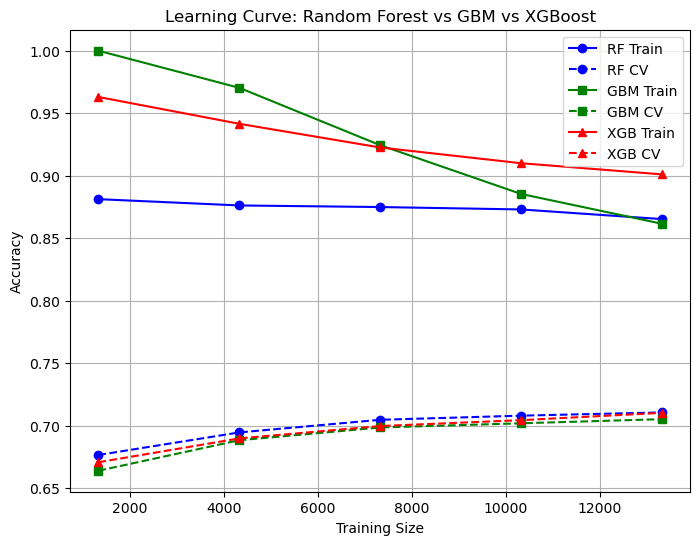

In [172]:
plt.figure(figsize=(8, 6))

plt.plot(train_sizes, rf_train_mean, 'o-', color='blue', label='RF Train')
plt.plot(train_sizes, rf_val_mean, 'o--', color='blue', label='RF CV')

plt.plot(train_sizes, lgbm_train_mean, 's-', color='green', label='GBM Train')
plt.plot(train_sizes, lgbm_val_mean, 's--', color='green', label='GBM CV')

plt.plot(train_sizes, xgb_train_mean, '^-', color='red', label='XGB Train')
plt.plot(train_sizes, xgb_val_mean, '^--', color='red', label='XGB CV')

plt.xlabel('Training Size')
plt.ylabel('Accuracy')
plt.title('Learning Curve: Random Forest vs GBM vs XGBoost')
plt.legend()
plt.grid(True)
plt.show()
